### Non-equilibrium thermodynamics

<img src="https://secure-ecsd.elsevier.com/covers/80/Tango2/largest/9780443221491.jpg">

### Brownian motion

<img src="https://upload.wikimedia.org/wikipedia/commons/c/c2/Brownian_motion_large.gif">

### Thermal vibration of a segment of a protein's alpha helix

<img src="https://upload.wikimedia.org/wikipedia/commons/2/23/Thermally_Agitated_Molecule.gif">

### A visualization of sampling using Langevin Dynamics.

<img src="https://abdulfatir.com/assets/img/blogs/lmc/mala.png">

### The ink diffuses into water molecule

<img src="https://www.shutterstock.com/shutterstock/videos/17807884/thumb/8.jpg?ip=x480">

### Using Langevin dynamics to sample from a mixture of two Gaussians

<img src="https://yang-song.net/assets/img/score/langevin.gif">

<img src="https://www.sfu.ca/sonic-studio-webdav/handbook/Graphics/Gaussian.gif">

### Annealed Langevin dynamics for the Noise Conditional Score Network (NCSN) model

<img src="https://yang-song.net/assets/img/score/celeba_large.gif">

### An image starts with random noise and slowly diffuses into a meaninful picture

<img src="https://miro.medium.com/v2/resize:fit:786/format:webp/1*KuejfyJa2ts566nl5D6rLA.gif" >

In [ ]:
# ============================================================
# PyTorch Diffusion Lab — DDPM + DDIM + CFG (End-to-End)
# ============================================================
# Goal:
#   Build a clean, educational diffusion pipeline that matches the *real-world order*:
#   1) Data Input     2) Normalization     3) Noise Schedule
#   4) Forward Diff   5) Random t sample   6) Time Embedding
#   7) Conditioning   8) Denoiser (U-Net)  9) Attention inside
#   10) Loss (ε MSE)  11) Training
#   12) x_T ~ N(0,I)  13) Reverse Loop     14) DDPM vs DDIM
#   15) CFG           16) Final samples    17) (Optional) decoder note
#
# Notes:
# - No torchvision (some environments break). We use sklearn digits, upscaled to 32x32.
# - Conditioning is class-based (like "text conditioning" conceptually, but simpler).
# - Visualization is included for every major step.

import math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits # MNIST

In [ ]:
# -------------------------
# 0) Setup: seeds + device
# -------------------------
SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
# -------------------------------------------
# Helper: pretty image grids (diffusion view)
# -------------------------------------------
def to_01(x): # Diffusion model prefer the pixel values to be in the range [-1, 1]

    # diffusion convention: [-1,1] -> [0,1] for plotting
    return ((x + 1) / 2).clamp(min=0, max=1)

In [ ]:
my_tensor = torch.tensor([-5, -4, 0, 1, 3, 5])

my_tensor.clamp(min=-4, max=3)

tensor([-4, -4,  0,  1,  3,  3])

In [ ]:
math.sqrt(16) # The total number of imgs is 16

4.0

In [ ]:
math.ceil(10 / 3)

4

In [ ]:
10 / 3

3.3333333333333335

In [ ]:
def show_grid(x, title="", n=16):

    x = x[:n].detach().cpu()

    x = to_01(x) # Convert [-1, 1] to [0, 1]

    cols = int(math.sqrt(n))
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols*2, rows*2))

    for i in range(n): # Iterates over all images inside the batch
        plt.subplot(rows, cols, i+1) # Activates the Ith position
        plt.imshow(x[i,0], cmap="gray") # MNIST
        plt.axis("off") # turning off the axes
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
def show_row(images, titles, supertitle=""):

    plt.figure(figsize=(2.2*len(images), 2.5))

    for i, (img, ttl) in enumerate(zip(images, titles)):

        plt.subplot(1, len(images), i+1) # Activating the ith position
        plt.imshow(to_01(img)[0,0].detach().cpu(), cmap="gray")
        plt.axis("off")
        plt.title(ttl)
    plt.suptitle(supertitle)
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# 1️⃣ Raw Data Input (Training Data)
# ============================================================
digits = load_digits()

X = digits.images.astype(np.float32)     # (N, 8, 8) in [0..16]
Y = digits.target.astype(np.int64)       # (N,)

In [ ]:
digits.images.astype(np.float32).dtype

dtype('float32')

In [ ]:
digits.target.astype(np.int64)[:100]

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1,
       2, 3, 4, 5, 6, 7, 8, 9, 0, 9, 5, 5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7,
       7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2, 0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6,
       6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8, 2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4,
       6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3, 1])

In [ ]:
X

array([[[ 0.,  0.,  5., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ..., 15.,  5.,  0.],
        [ 0.,  3., 15., ..., 11.,  8.,  0.],
        ...,
        [ 0.,  4., 11., ..., 12.,  7.,  0.],
        [ 0.,  2., 14., ..., 12.,  0.,  0.],
        [ 0.,  0.,  6., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  5.,  0.,  0.],
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  0.,  3., ...,  6.,  0.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 12.,  0.,  0.],
        [ 0.,  0.,  3., ..., 14.,  0.,  0.],
        [ 0.,  0.,  8., ..., 16.,  0.,  0.],
        ...,
        [ 0.,  9., 16., ...,  0.,  0.,  0.],
        [ 0.,  3., 13., ..., 11.,  5.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.]],

       ...,

       [[ 0.,  0.,  1., ...,  1.,  0.,  0.],
        [ 0.,  0., 13., ...,  2.,  1.,  0.],
        [ 0.,  0., 16., ..., 16.,  5.,  0.

In [ ]:
X.shape

(1797, 8, 8)

In [ ]:
X.shape

(1797, 8, 8)

In [ ]:
Y

array([0, 1, 2, ..., 8, 9, 8])

In [ ]:
Y.shape

(1797,)

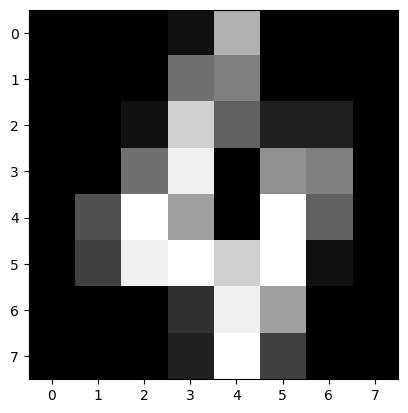

In [ ]:
plt.imshow(X[4], cmap="gray")
plt.show()

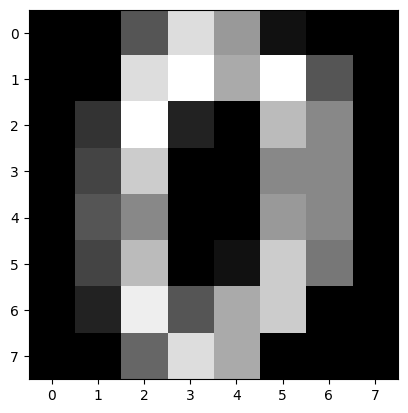

In [ ]:
plt.imshow(X[0], cmap="gray")
plt.show()

In [ ]:
X[8].min()

np.float32(0.0)

In [ ]:
X[0].max()

np.float32(15.0)

In [ ]:
(X[0] / 16.0).min(), (X[0] / 16.0).max()

(np.float32(0.0), np.float32(0.9375))

In [ ]:
torch.from_numpy((((X[0] / 16.0) * 2.0) - 1))

tensor([[-1.0000, -1.0000, -0.3750,  0.6250,  0.1250, -0.8750, -1.0000, -1.0000],
        [-1.0000, -1.0000,  0.6250,  0.8750,  0.2500,  0.8750, -0.3750, -1.0000],
        [-1.0000, -0.6250,  0.8750, -0.7500, -1.0000,  0.3750,  0.0000, -1.0000],
        [-1.0000, -0.5000,  0.5000, -1.0000, -1.0000,  0.0000,  0.0000, -1.0000],
        [-1.0000, -0.3750,  0.0000, -1.0000, -1.0000,  0.1250,  0.0000, -1.0000],
        [-1.0000, -0.5000,  0.3750, -1.0000, -0.8750,  0.5000, -0.1250, -1.0000],
        [-1.0000, -0.7500,  0.7500, -0.3750,  0.2500,  0.5000, -1.0000, -1.0000],
        [-1.0000, -1.0000, -0.2500,  0.6250,  0.2500, -1.0000, -1.0000, -1.0000]])

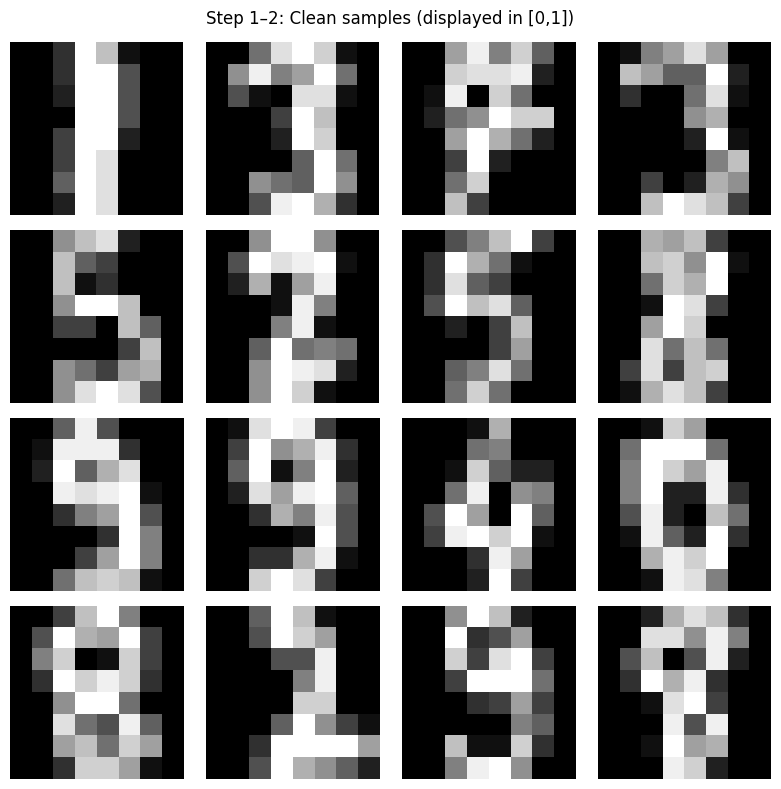

x0 shape: (128, 1, 32, 32) | range: -1.0 to 1.0


In [ ]:
# ============================================================
# 2️⃣ Data Normalization  (common: scale to [-1, 1])
# ============================================================

# Data Normalization
X = X / 16.0         # Step A : Scale [0,1]
X = X * 2.0 - 1.0    # Step B: Sclae to [-1,1]

# Inserting a new dimension (new axis) to the image arrays
X = X[:, None, :, :] # (N, 1, 8, 8) # Inserting (Injecting) Dummy Dimension

# Converting numpy array into pytorch tensors
X = torch.from_numpy(X)
Y = torch.from_numpy(Y)

# Optional: upscale (purely for nicer denoising / U-Net capacity)
X = F.interpolate(X, size=(32, 32), mode="nearest")

ds = TensorDataset(X, Y) # Convert the (X, y) (Image, Label) Pytorch Dataset to be able to pass it to the model

dl = DataLoader(ds, batch_size=128, shuffle=True, num_workers=0)

x0, y0 = next(iter(dl))
show_grid(x0, "Step 1–2: Clean samples (displayed in [0,1])")
print("x0 shape:", tuple(x0.shape), "| range:", float(x0.min()), "to", float(x0.max()))


$$\bar{\alpha}_t = \cos^2 \left( \frac{t/T + s}{1 + s} \cdot \frac{\pi}{2} \right)$$

The squared cosine shape is perfect because it starts flat (preserving signal), drops smoothly in the middle, and flattens out at the end (preventing a sudden "crash" to zero signal).

In [ ]:
1e-4

0.0001

In [ ]:
torch.linspace(0.0001, 0.02, 50)

tensor([1.0000e-04, 5.0612e-04, 9.1224e-04, 1.3184e-03, 1.7245e-03, 2.1306e-03,
        2.5367e-03, 2.9429e-03, 3.3490e-03, 3.7551e-03, 4.1612e-03, 4.5673e-03,
        4.9735e-03, 5.3796e-03, 5.7857e-03, 6.1918e-03, 6.5980e-03, 7.0041e-03,
        7.4102e-03, 7.8163e-03, 8.2224e-03, 8.6286e-03, 9.0347e-03, 9.4408e-03,
        9.8469e-03, 1.0253e-02, 1.0659e-02, 1.1065e-02, 1.1471e-02, 1.1878e-02,
        1.2284e-02, 1.2690e-02, 1.3096e-02, 1.3502e-02, 1.3908e-02, 1.4314e-02,
        1.4720e-02, 1.5127e-02, 1.5533e-02, 1.5939e-02, 1.6345e-02, 1.6751e-02,
        1.7157e-02, 1.7563e-02, 1.7969e-02, 1.8376e-02, 1.8782e-02, 1.9188e-02,
        1.9594e-02, 2.0000e-02])

In [ ]:
torch.arange(0, 10, 2, dtype=torch.float32)

tensor([0., 2., 4., 6., 8.])

In [ ]:
# ============================================================
# 3️⃣ Define the Noise Schedule (βₜ, αₜ, ᾱₜ)
# ============================================================

def beta_schedule(T, kind="cosine", beta_start=1e-4, beta_end=0.02):

    if kind == "linear":

        return torch.linspace(beta_start, beta_end, T)

    if kind == "cosine":

        # Improved DDPM cosine schedule

        s = 0.008 # Offset

        steps = torch.arange(T + 1, dtype=torch.float32)

        t = steps / T

        a_bar = torch.cos(((t + s) / (1 + s)) * math.pi / 2) ** 2 # The remaining signal in the image

        a_bar = a_bar / a_bar[0] # Normalization factor

        betas = 1 - (a_bar[1:] / a_bar[:-1]) # 1 - signal = noise

        return betas.clamp(1e-5, 0.999)

    raise ValueError("kind must be 'linear' or 'cosine'")

In [ ]:
beta_schedule(200, kind="cosine").to(device)

tensor([2.5499e-04, 3.7640e-04, 4.9782e-04, 6.1941e-04, 7.4095e-04, 8.6260e-04,
        9.8437e-04, 1.1061e-03, 1.2280e-03, 1.3503e-03, 1.4725e-03, 1.5949e-03,
        1.7174e-03, 1.8404e-03, 1.9631e-03, 2.0865e-03, 2.2099e-03, 2.3338e-03,
        2.4577e-03, 2.5820e-03, 2.7066e-03, 2.8315e-03, 2.9567e-03, 3.0823e-03,
        3.2083e-03, 3.3347e-03, 3.4615e-03, 3.5887e-03, 3.7163e-03, 3.8444e-03,
        3.9729e-03, 4.1022e-03, 4.2318e-03, 4.3617e-03, 4.4926e-03, 4.6237e-03,
        4.7557e-03, 4.8881e-03, 5.0212e-03, 5.1550e-03, 5.2894e-03, 5.4243e-03,
        5.5603e-03, 5.6970e-03, 5.8342e-03, 5.9724e-03, 6.1111e-03, 6.2512e-03,
        6.3916e-03, 6.5333e-03, 6.6757e-03, 6.8190e-03, 6.9634e-03, 7.1086e-03,
        7.2550e-03, 7.4024e-03, 7.5508e-03, 7.7004e-03, 7.8511e-03, 8.0031e-03,
        8.1559e-03, 8.3104e-03, 8.4660e-03, 8.6229e-03, 8.7810e-03, 8.9408e-03,
        9.1016e-03, 9.2642e-03, 9.4281e-03, 9.5937e-03, 9.7606e-03, 9.9294e-03,
        1.0100e-02, 1.0272e-02, 1.0446e-

In [ ]:
1 - beta_schedule(200, kind="cosine").to(device)

tensor([0.9997, 0.9996, 0.9995, 0.9994, 0.9993, 0.9991, 0.9990, 0.9989, 0.9988,
        0.9986, 0.9985, 0.9984, 0.9983, 0.9982, 0.9980, 0.9979, 0.9978, 0.9977,
        0.9975, 0.9974, 0.9973, 0.9972, 0.9970, 0.9969, 0.9968, 0.9967, 0.9965,
        0.9964, 0.9963, 0.9962, 0.9960, 0.9959, 0.9958, 0.9956, 0.9955, 0.9954,
        0.9952, 0.9951, 0.9950, 0.9948, 0.9947, 0.9946, 0.9944, 0.9943, 0.9942,
        0.9940, 0.9939, 0.9937, 0.9936, 0.9935, 0.9933, 0.9932, 0.9930, 0.9929,
        0.9927, 0.9926, 0.9924, 0.9923, 0.9921, 0.9920, 0.9918, 0.9917, 0.9915,
        0.9914, 0.9912, 0.9911, 0.9909, 0.9907, 0.9906, 0.9904, 0.9902, 0.9901,
        0.9899, 0.9897, 0.9896, 0.9894, 0.9892, 0.9890, 0.9888, 0.9887, 0.9885,
        0.9883, 0.9881, 0.9879, 0.9877, 0.9875, 0.9873, 0.9871, 0.9869, 0.9867,
        0.9865, 0.9863, 0.9861, 0.9858, 0.9856, 0.9854, 0.9852, 0.9849, 0.9847,
        0.9845, 0.9842, 0.9840, 0.9837, 0.9835, 0.9832, 0.9830, 0.9827, 0.9824,
        0.9821, 0.9819, 0.9816, 0.9813, 

In [ ]:
torch.cumprod(1 - beta_schedule(200, kind="cosine").to(device), dim=0)

tensor([9.9975e-01, 9.9937e-01, 9.9887e-01, 9.9825e-01, 9.9751e-01, 9.9665e-01,
        9.9567e-01, 9.9457e-01, 9.9335e-01, 9.9201e-01, 9.9055e-01, 9.8897e-01,
        9.8727e-01, 9.8545e-01, 9.8352e-01, 9.8146e-01, 9.7930e-01, 9.7701e-01,
        9.7461e-01, 9.7209e-01, 9.6946e-01, 9.6672e-01, 9.6386e-01, 9.6089e-01,
        9.5780e-01, 9.5461e-01, 9.5131e-01, 9.4789e-01, 9.4437e-01, 9.4074e-01,
        9.3700e-01, 9.3316e-01, 9.2921e-01, 9.2516e-01, 9.2100e-01, 9.1674e-01,
        9.1238e-01, 9.0792e-01, 9.0336e-01, 8.9871e-01, 8.9395e-01, 8.8910e-01,
        8.8416e-01, 8.7912e-01, 8.7399e-01, 8.6877e-01, 8.6346e-01, 8.5807e-01,
        8.5258e-01, 8.4701e-01, 8.4136e-01, 8.3562e-01, 8.2980e-01, 8.2390e-01,
        8.1793e-01, 8.1187e-01, 8.0574e-01, 7.9954e-01, 7.9326e-01, 7.8691e-01,
        7.8049e-01, 7.7401e-01, 7.6745e-01, 7.6084e-01, 7.5415e-01, 7.4741e-01,
        7.4061e-01, 7.3375e-01, 7.2683e-01, 7.1986e-01, 7.1283e-01, 7.0575e-01,
        6.9863e-01, 6.9145e-01, 6.8423e-

In [ ]:
torch.sqrt(torch.cumprod(1 - beta_schedule(200, kind="cosine").to(device), dim=0))

tensor([9.9987e-01, 9.9968e-01, 9.9944e-01, 9.9913e-01, 9.9876e-01, 9.9832e-01,
        9.9783e-01, 9.9728e-01, 9.9667e-01, 9.9600e-01, 9.9526e-01, 9.9447e-01,
        9.9361e-01, 9.9270e-01, 9.9172e-01, 9.9069e-01, 9.8959e-01, 9.8844e-01,
        9.8722e-01, 9.8595e-01, 9.8461e-01, 9.8322e-01, 9.8176e-01, 9.8025e-01,
        9.7867e-01, 9.7704e-01, 9.7535e-01, 9.7360e-01, 9.7179e-01, 9.6992e-01,
        9.6799e-01, 9.6600e-01, 9.6395e-01, 9.6185e-01, 9.5969e-01, 9.5747e-01,
        9.5519e-01, 9.5285e-01, 9.5045e-01, 9.4800e-01, 9.4549e-01, 9.4292e-01,
        9.4030e-01, 9.3762e-01, 9.3488e-01, 9.3208e-01, 9.2923e-01, 9.2632e-01,
        9.2335e-01, 9.2033e-01, 9.1726e-01, 9.1412e-01, 9.1093e-01, 9.0769e-01,
        9.0439e-01, 9.0104e-01, 8.9763e-01, 8.9417e-01, 8.9065e-01, 8.8708e-01,
        8.8345e-01, 8.7978e-01, 8.7604e-01, 8.7226e-01, 8.6842e-01, 8.6453e-01,
        8.6059e-01, 8.5659e-01, 8.5254e-01, 8.4844e-01, 8.4429e-01, 8.4009e-01,
        8.3584e-01, 8.3153e-01, 8.2718e-

In [ ]:
torch.sqrt(1 - (torch.cumprod(1 - beta_schedule(200, kind="cosine").to(device), dim=0)))

tensor([0.0160, 0.0251, 0.0336, 0.0418, 0.0499, 0.0579, 0.0658, 0.0737, 0.0816,
        0.0894, 0.0972, 0.1050, 0.1128, 0.1206, 0.1284, 0.1361, 0.1439, 0.1516,
        0.1593, 0.1671, 0.1748, 0.1824, 0.1901, 0.1978, 0.2054, 0.2130, 0.2207,
        0.2283, 0.2359, 0.2434, 0.2510, 0.2585, 0.2661, 0.2736, 0.2811, 0.2885,
        0.2960, 0.3034, 0.3109, 0.3183, 0.3256, 0.3330, 0.3404, 0.3477, 0.3550,
        0.3623, 0.3695, 0.3767, 0.3840, 0.3911, 0.3983, 0.4054, 0.4126, 0.4196,
        0.4267, 0.4337, 0.4407, 0.4477, 0.4547, 0.4616, 0.4685, 0.4754, 0.4822,
        0.4890, 0.4958, 0.5026, 0.5093, 0.5160, 0.5227, 0.5293, 0.5359, 0.5424,
        0.5490, 0.5555, 0.5619, 0.5684, 0.5748, 0.5811, 0.5874, 0.5937, 0.6000,
        0.6062, 0.6124, 0.6185, 0.6246, 0.6307, 0.6367, 0.6427, 0.6487, 0.6546,
        0.6605, 0.6663, 0.6721, 0.6778, 0.6835, 0.6892, 0.6948, 0.7004, 0.7059,
        0.7114, 0.7169, 0.7223, 0.7277, 0.7330, 0.7383, 0.7435, 0.7487, 0.7538,
        0.7589, 0.7640, 0.7690, 0.7740, 

In [ ]:
# ============================================================
# 3️.1 Using the above function of scheduling noise addition
# ============================================================

T_STEPS = 200 # Choosing the amount of timesteps that we want to use

betas = beta_schedule(T_STEPS, kind="cosine").to(device)

alphas = 1.0 - betas

alpha_bar = torch.cumprod(alphas, dim=0)

# The reparameterization trick

sqrt_alpha_bar = torch.sqrt(alpha_bar) # The scaling factor for the actual signals in the image

sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar) # The scaling factor of the beta which represents the amount of variance added to the image

sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

alpha_bar_prev = torch.cat([torch.tensor([1.0], device=device), alpha_bar[:-1]])

posterior_variance = betas * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar)

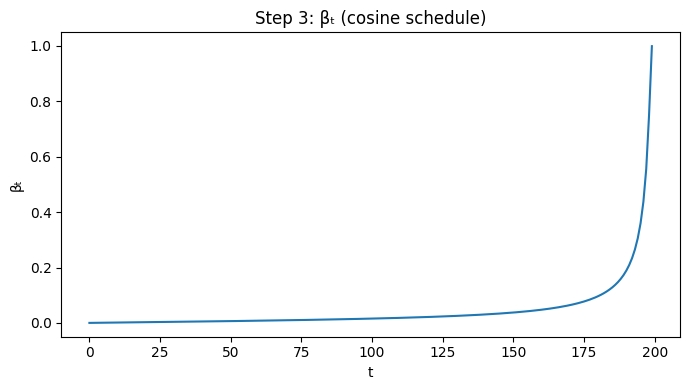

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(betas.detach().cpu().numpy())
plt.title("Step 3: βₜ (cosine schedule)")
plt.xlabel("t"); plt.ylabel("βₜ"); plt.tight_layout(); plt.show()

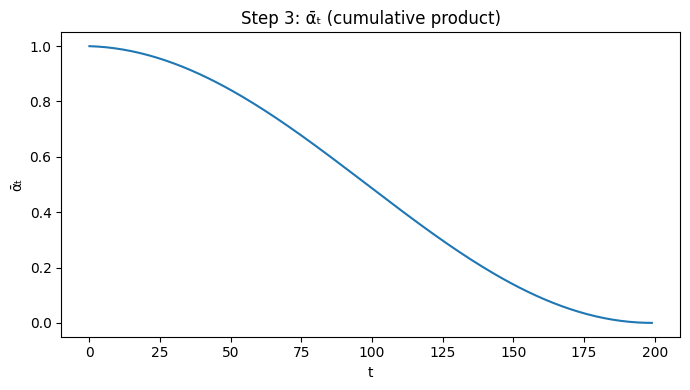

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(alpha_bar.detach().cpu().numpy())
plt.title("Step 3: ᾱₜ (cumulative product)")
plt.xlabel("t"); plt.ylabel("ᾱₜ"); plt.tight_layout(); plt.show()

$$x_t = \sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon$$

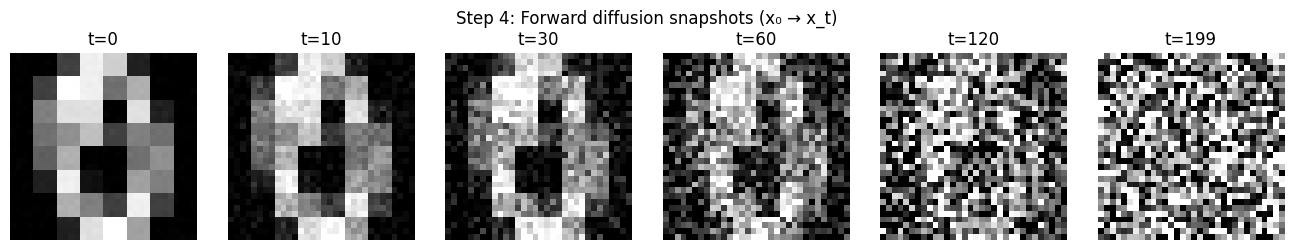

In [ ]:
# ============================================================
# 4️⃣ Forward Diffusion (Noise Injection): x_t = ...
# ============================================================

def extract(vec, t, x_shape): # [128, 1, 32, 32]
    # vec: [T], t: [B] -> [B,1,1,1] broadcasting

    out = vec.gather(0, t)
    return out.view(t.shape[0], *((1,) * (len(x_shape) - 1))) # Broadcasted version of the array

def q_sample(x0, t, eps=None):
    # x_t = sqrt(ᾱ_t)x0 + sqrt(1-ᾱ_t)ε
    if eps is None:
        eps = torch.randn_like(x0)

    return extract(sqrt_alpha_bar, t, x0.shape) * x0 + extract(sqrt_one_minus_alpha_bar, t, x0.shape) * eps

x0, _ = next(iter(dl)) # DataLoader
x0 = x0.to(device)

ts = torch.tensor([0, 10, 30, 60, 120, 199], device=device, dtype=torch.long)
noisy_list = []
for tv in ts:
    t = torch.full((x0.size(0),), int(tv.item()), device=device, dtype=torch.long)
    noisy_list.append(q_sample(x0, t))

show_row(noisy_list, [f"t={int(t.item())}" for t in ts], "Step 4: Forward diffusion snapshots (x₀ → x_t)")

In [ ]:
# ============================================================
# 5️⃣ Random Timestep Sampling (Training Trick)
# ============================================================
# We'll do this inside training_step() by sampling t ~ Uniform{0..T-1} per sample.

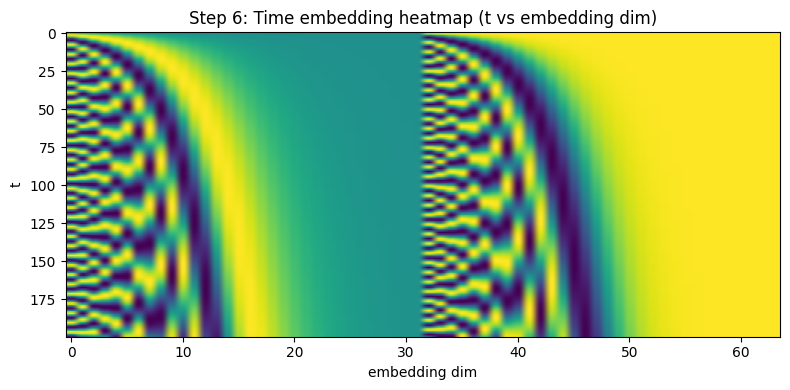

In [ ]:
# ============================================================
# 6️⃣ Timestep Encoding (Sinusoidal Time Embeddings)
# ============================================================

class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim): # 0 -> Vector[64]
        super().__init__()
        self.dim = dim

    def forward(self, t):  # t: [B] int

        half = self.dim // 2 # We split the dimensions into two groups: one for sin and one for cos.

        # This is a standard scaling factor. It ensures the frequencies range from 2pi to $10,000 * 2pi.
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1))

        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0,1))
        return emb  # [B, dim]

E = SinusoidalTimeEmbedding(64).to(device)(torch.arange(0, T_STEPS, device=device)).detach().cpu()
plt.figure(figsize=(8,4))
plt.imshow(E.numpy(), aspect="auto")
plt.title("Step 6: Time embedding heatmap (t vs embedding dim)")
plt.xlabel("embedding dim"); plt.ylabel("t"); plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# 7️⃣ Optional Conditioning Input (here: class-conditioning)
# ============================================================
# Real-world analogy:
# - Stable Diffusion: conditioning comes from text encoder embeddings
# - Here: conditioning comes from a class embedding (0..9)
#
# We'll also implement CFG (Classifier-Free Guidance) by randomly dropping the condition.

In [ ]:
# ============================================================
# 8️⃣ Core Network: Denoising Model (Tiny U-Net)
# 9️⃣ Internal Architecture: Residual + Attention blocks
# ============================================================

class ResBlock(nn.Module):

    def __init__(self, in_ch, out_ch, time_dim, cond_dim):  # Embedding (5)

        super().__init__()

        self.norm1 = nn.GroupNorm(8, in_ch) # Batch Norm

        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)

        self.norm2 = nn.GroupNorm(8, out_ch)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.to_time = nn.Linear(time_dim, out_ch)

        self.to_cond = nn.Linear(cond_dim, out_ch) if cond_dim > 0 else None

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb, c_emb=None):

        h = self.conv1(F.silu(self.norm1(x))) # Swich (SilU Activation Function)
        h = h + self.to_time(t_emb).unsqueeze(-1).unsqueeze(-1)

        if self.to_cond is not None and c_emb is not None:
            h = h + self.to_cond(c_emb).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

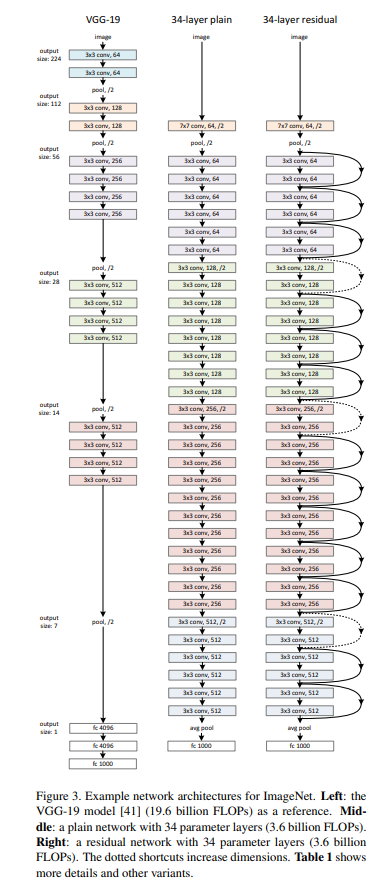
# https://arxiv.org/pdf/1512.03385

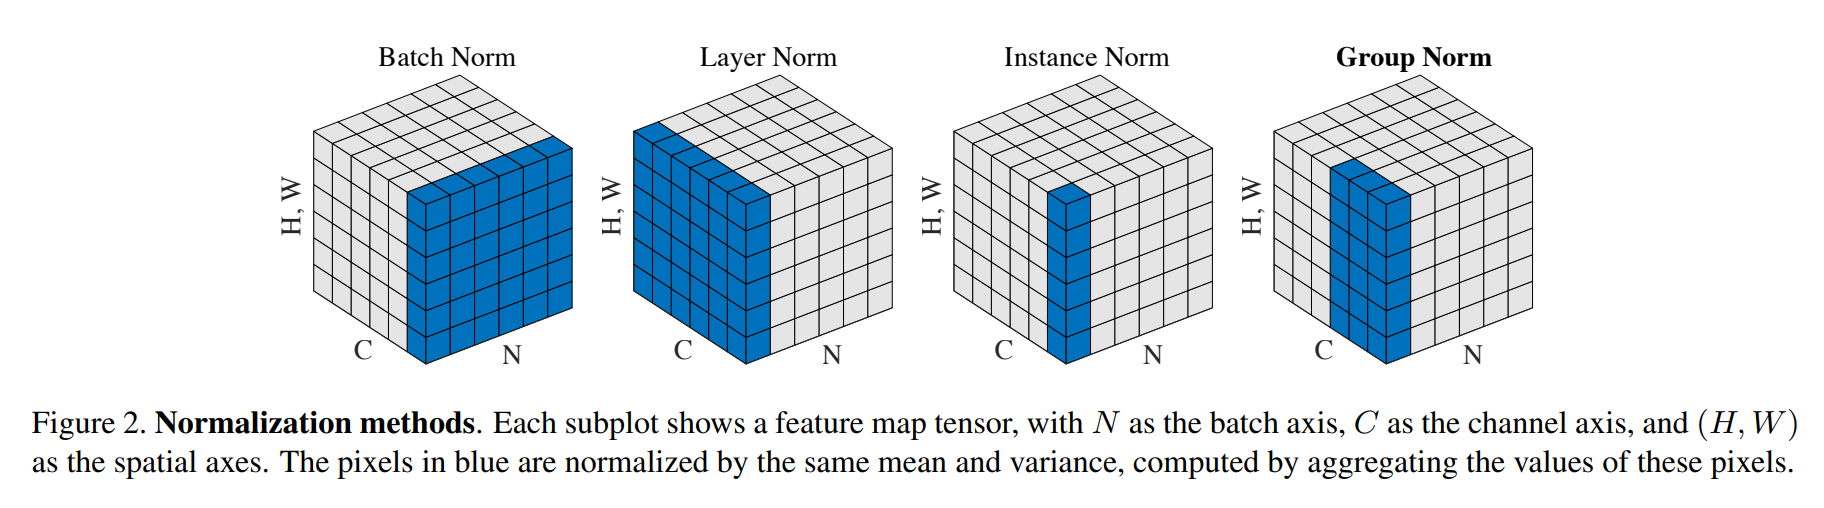
# https://arxiv.org/pdf/1803.08494

In [ ]:
from transformers import AutoModelForCausalLM

In [ ]:
gpt2 = AutoModelForCausalLM.from_pretrained("gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [ ]:
gpt2

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
class SelfAttention2d(nn.Module):

    # "Transformer-ish" block: QKV attention over H*W tokens
    def __init__(self, ch, heads=4):
        super().__init__()

        self.norm = nn.GroupNorm(8, ch) # Batch size = 5

        self.qkv = nn.Conv1d(ch, ch*3, 1) # mathematically equalivant a regular linear layer
        self.proj = nn.Conv1d(ch, ch, 1)
        self.heads = heads

    def forward(self, x): # X -> Input Data

        B, C, H, W = x.shape # Unpacking the dimension shape into 4 different variables
        h = self.norm(x).view(B, C, H*W)           # tokens
        q, k, v = self.qkv(h).chunk(3, dim=1)

        d = C // self.heads

        q = q.view(B, self.heads, d, H*W)
        k = k.view(B, self.heads, d, H*W)
        v = v.view(B, self.heads, d, H*W)

        # b: Batch size.
        # h: Number of attention heads.
        # n: Query sequence length (the number of "pixels" or tokens looking for info).
        # m: Key/Value sequence length (the number of "pixels" being looked at).
        # d: Dimension of each head (the "depth" or feature size).

        attn = torch.einsum("bhdn,bhdm->bhnm", q, k) / math.sqrt(d)
        attn = attn.softmax(dim=-1)
        out = torch.einsum("bhnm,bhdm->bhdn", attn, v).reshape(B, C, H*W)

        out = self.proj(out).view(B, C, H, W)
        return x + out  # residual

In [ ]:
class TinyUNet(nn.Module):


    def __init__(self, in_ch=1, base=64, time_dim=128, num_classes=10, use_attn=True):

        super().__init__()

        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(), # introduces non-linearties into the learning process
            nn.Linear(time_dim, time_dim),
        )


        self.class_emb = nn.Embedding(num_classes, time_dim)  # conditioning vector

        self.null_cond = nn.Parameter(torch.zeros(time_dim))  # "unconditional token" for CFG

        # Down (The Contracting Path)
        self.in_conv = nn.Conv2d(in_ch, base, 3, padding=1)

        self.down1 = ResBlock(base, base, time_dim, time_dim)

        self.down2 = ResBlock(base, base*2, time_dim, time_dim)

        self.pool = nn.AvgPool2d(2) # is to reduce (Compress) the images size into half of the oiginal image.

        # Middle
        self.mid1 = ResBlock(base*2, base*2, time_dim, time_dim)

        self.attn = SelfAttention2d(base*2) if use_attn else nn.Identity()

        self.mid2 = ResBlock(base*2, base*2, time_dim, time_dim)

        # Up
        self.up1 = ResBlock(base*2 + base*2, base, time_dim, time_dim)

        self.up2 = ResBlock(base + base, base, time_dim, time_dim)

        self.out_norm = nn.GroupNorm(8, base)

        self.out_conv = nn.Conv2d(base, in_ch, 3, padding=1)

    def forward(self, x, t, y=None):

        t_emb = self.time_mlp(t)  # [B, time_dim]

        # conditioning vector:
        # - if y is None -> unconditional path (CFG)
        # - else -> class embedding
        if y is None:
            c_emb = self.null_cond.unsqueeze(0).repeat(x.size(0), 1) # [B, C, H, W]
        else:
            c_emb = self.class_emb(y) # 5

        # Down
        x_in = self.in_conv(x)
        d1 = self.down1(x_in, t_emb, c_emb)
        p1 = self.pool(d1)  # Reducing the spatial dimensions

        d2 = self.down2(p1, t_emb, c_emb)

        p2 = self.pool(d2)

        # Mid
        m = self.mid1(p2, t_emb, c_emb)
        m = self.attn(m)
        m = self.mid2(m, t_emb, c_emb)

        # Up
        u1 = F.interpolate(m, scale_factor=2, mode="nearest")
        u1 = torch.cat([u1, d2], dim=1)
        u1 = self.up1(u1, t_emb, c_emb)

        u2 = F.interpolate(u1, scale_factor=2, mode="nearest")
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up2(u2, t_emb, c_emb) # ResBlock

        return self.out_conv(F.silu(self.out_norm(u2)))  # ε̂

In [ ]:
model = TinyUNet().to(device)

print("Denoiser params:", sum(p.numel() for p in model.parameters())/1e6, "M")

Denoiser params: 1.467201 M


In [ ]:
# ============================================================
# 🔟 Training Objective: L = E ||ε - εθ(x_t, t, cond)||²
# ============================================================
# No logits. No softmax. No tokens. Just: "predict the noise we injected."

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
CFG_DROP_PROB = 0.15  # train unconditional branch too

def training_step(x0, y):
    B = x0.size(0) # Batch size

    # 5️⃣ Random timestep per sample
    t = torch.randint(0, T_STEPS, (B,), device=device, dtype=torch.long) # long => integer

    # true injected noise
    eps = torch.randn_like(x0)

    # 4️⃣ forward diffuse
    xt = q_sample(x0, t, eps)

    # 7️⃣ classifier-free dropout (sometimes remove condition)
    keep_cond = (torch.rand(B, device=device) > CFG_DROP_PROB)
    y_eff = y.clone()
    y_eff[~keep_cond] = -1  # marker; we'll route those to y=None

    eps_hat = torch.empty_like(eps)
    if keep_cond.any():
        idx = keep_cond
        eps_hat[idx] = model(xt[idx], t[idx], y=y[idx])
    if (~keep_cond).any():
        idx = ~keep_cond
        eps_hat[idx] = model(xt[idx], t[idx], y=None)

    # 🔟 MSE loss
    loss = F.mse_loss(eps_hat, eps)
    return loss

In [ ]:
# ============================================================
# 1️⃣1️⃣ Model Training (minimal but complete)
# ============================================================
model.train() #  Set into training mode
losses = []
TRAIN_STEPS = 600

t0 = time.time()
it = iter(dl) # dl = data loader

for step in range(1, TRAIN_STEPS + 1): # 601
    try:
        x0, y = next(it)
    except StopIteration:
        it = iter(dl)
        x0, y = next(it)

    x0, y = x0.to(device), y.to(device)

    optimizer.zero_grad(set_to_none=True) # Clear out the gradients

    loss = training_step(x0, y) # MSE = Mean Squared Error (Loss function popular for Diffusion models)

    loss.backward()

    nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Exploding Gradients

    optimizer.step()

    losses.append(float(loss.item())) # Float
    if step % 100 == 0:
        print(f"train step {step:4d}/{TRAIN_STEPS} | loss {losses[-1]:.4f}")

print(f"Training done in {time.time()-t0:.1f}s")

train step  100/600 | loss 0.0629
train step  200/600 | loss 0.0441
train step  300/600 | loss 0.0402
train step  400/600 | loss 0.0333
train step  500/600 | loss 0.0303
train step  600/600 | loss 0.0174
Training done in 54.4s


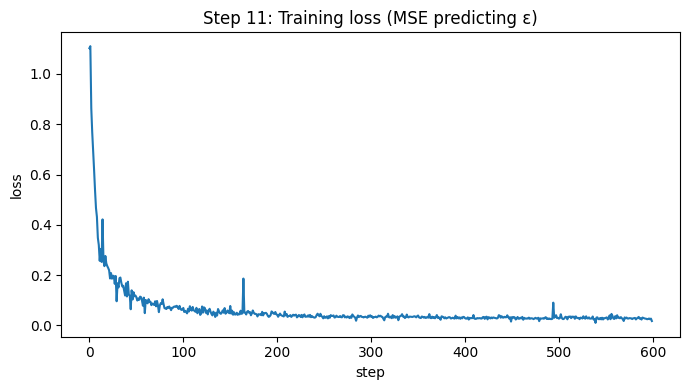

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(losses)
plt.title("Step 11: Training loss (MSE predicting ε)")
plt.xlabel("step");
plt.ylabel("loss")
plt.tight_layout();
plt.show()

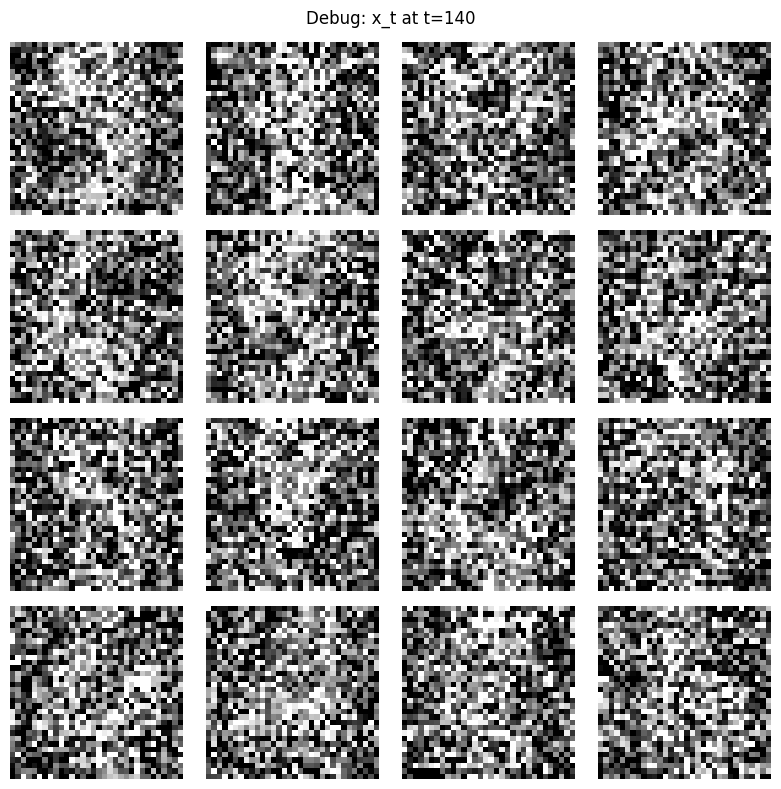

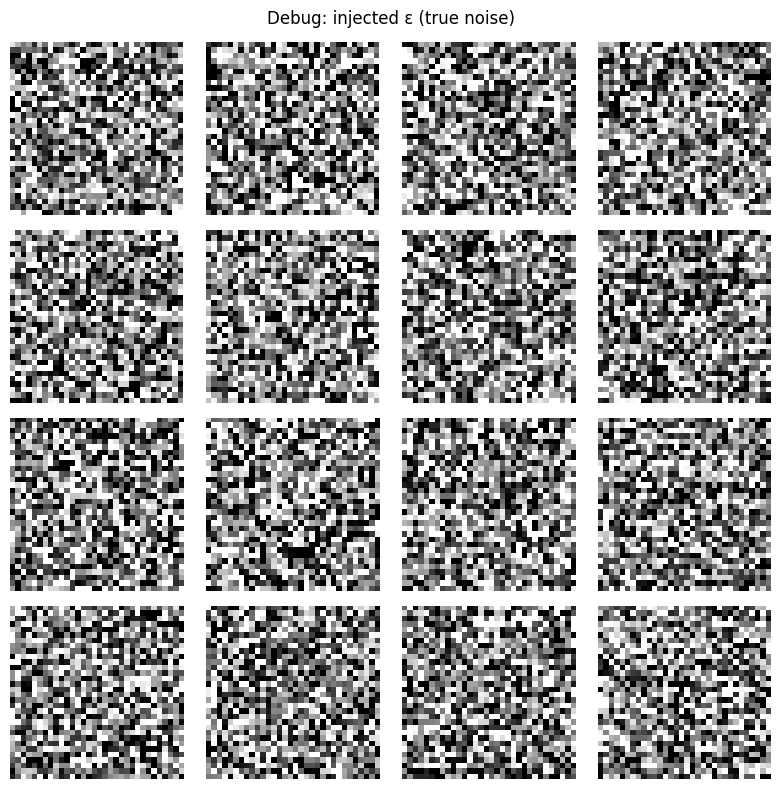

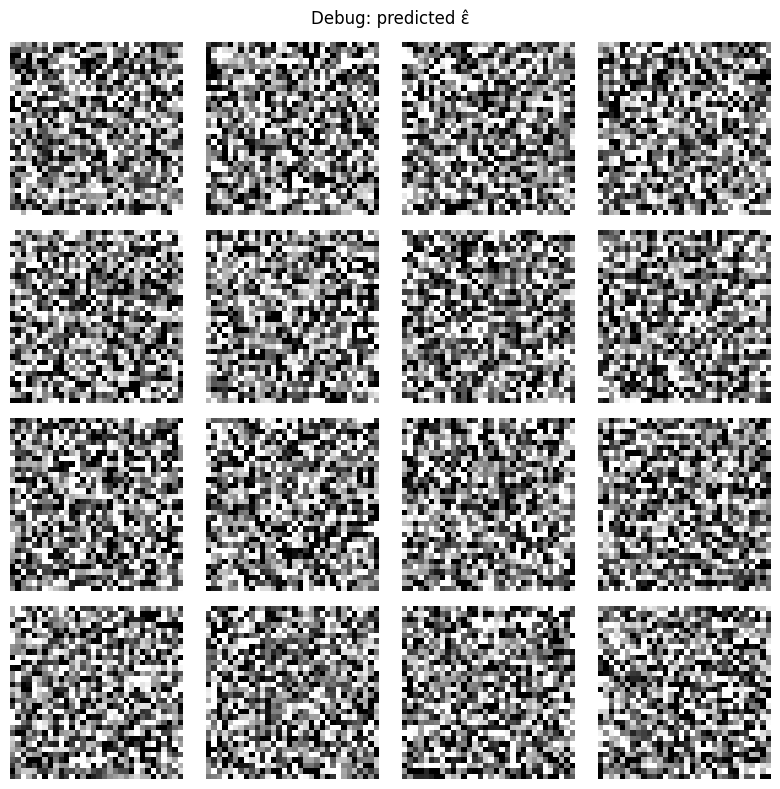

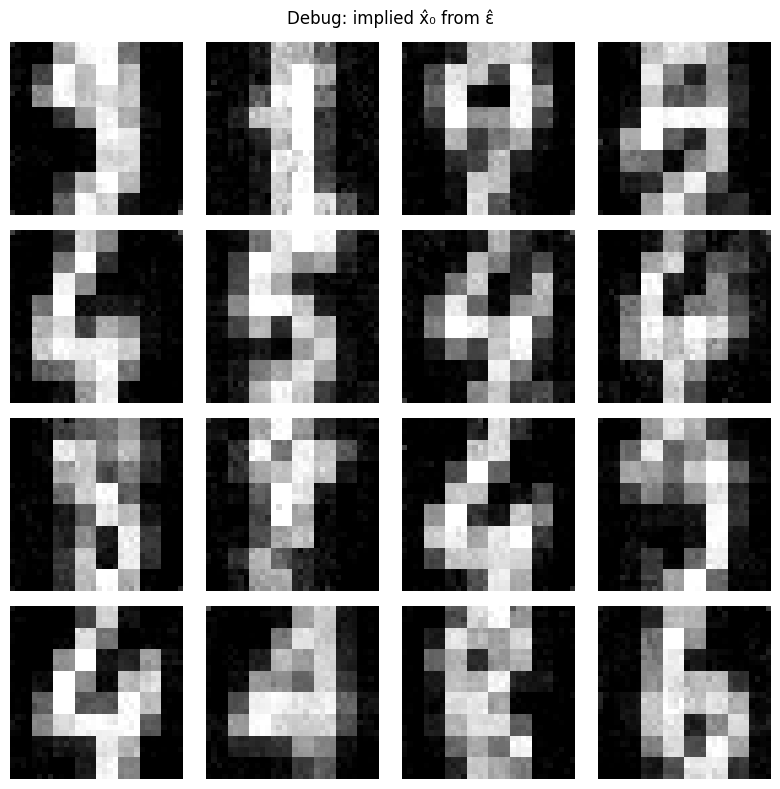

In [ ]:
# Debug visualization: x_t, ε, ε̂, inferred x̂₀
@torch.no_grad() # Disables the gradient computation (this is an inference-only block)

# defining a function to actually do the process of removing noise
def debug_one_batch(t_level=140, n=16):
    model.eval() # swtich off training-sepecific behaviour

    # Getting  a  batch of dataset by returning inside variables
    # X0 - the clean images (the inital images that are clean)
    # y - class labels associated with those images
    x0, y = next(iter(dl))

    # Transfer the data to CPU/GPU device depending on avaiability
    x0, y = x0.to(device), y.to(device)

    B = x0.size(0) # every batch contains 16 different images
    # Torch.long is equilivant to torch.int64
    t = torch.full((B,), t_level, device=device, dtype=torch.long)
    # Draw fresh gaussian noise
    eps = torch.randn_like(x0)
    # Run a forward diffusion process (q_sample())
    xt = q_sample(x0, t, eps) # corruping our images gradually by adding different amount of noises

    # we are passing the model 3 different signals
    # 1. the noisy images
    # 2. t - the current timestamp
    # 3. y the ground-truth class

    # first we start with a clean image
    # we add different amount of noise by gradually taking noise from gaussian normal distr
    # run the model to estimate/predict the amount of noise
    eps_hat = model(xt, t, y=y)

    # x̂₀ from ε̂
    x0_hat = (xt - extract(sqrt_one_minus_alpha_bar, t, xt.shape) * eps_hat) / extract(sqrt_alpha_bar, t, xt.shape)
    # Dispalying four grids:
    # 1. the noisy images
    # 2. Injected noise inside images
    # 3. Predicted Noise
    # 4. The infered images from removing that noise
    show_grid(xt, f"Debug: x_t at t={t_level}")
    show_grid(eps, "Debug: injected ε (true noise)")
    show_grid(eps_hat, "Debug: predicted ε̂")
    show_grid(x0_hat, "Debug: implied x̂₀ from ε̂")

debug_one_batch(t_level=140, n=16)

In [ ]:
# ============================================================
# Inference (Reverse Diffusion)
# 1️⃣2️⃣ Start from pure noise x_T ~ N(0,I)
# ============================================================


# in this block of code we will build a classifer free guidance

@torch.no_grad() # disabled the gradient tracking
def eps_cfg(x, t, y, s=3.0): # CFG-scale > 0
    # 1️⃣5️⃣ CFG: (1+s)ε_cond - s ε_uncond
    eps_uncond = model(x, t, y=None) # here we run the model frelly without a label

    eps_cond = model(x, t, y=y) # here we run a  model conditiond on a some label (class)

    return (1.0 + s) * eps_cond - s * eps_uncond

In [ ]:
# ============================================================
# 1️⃣3️⃣ Reverse Loop (DDPM)
# ============================================================
@torch.no_grad()
# running the forward diffusion process (which will add noise)
# recevies 4 params:
# 1. the noisy image
# 2. the current timestemp
# 3. y - the actual target label
# 4. cfg-scale - scale for controlling the gerneration process
def p_sample_ddpm(x, t_int, y=None, cfg_scale=0.0):
    B = x.size(0)

    t = torch.full((B,), t_int, device=device, dtype=torch.long)
    # an elegant way to check wheather to use CFG or not
    eps_hat = eps_cfg(x, t, y, s=cfg_scale) if (y is not None and cfg_scale > 0) else model(x, t, y=y)

    beta_t = extract(betas, t, x.shape)
    sqrt_1m_ab = extract(sqrt_one_minus_alpha_bar, t, x.shape)
    sqrt_recip_a = extract(sqrt_recip_alphas, t, x.shape)

    # in order to move freely between different timesteps
    # epsilon is a small value added to the division process so that it does not divide by zero
    # DDPM mean using ε-parameterization
    mu = sqrt_recip_a * (x - beta_t * eps_hat / (sqrt_1m_ab + 1e-8))

    if t_int == 0:
        return mu

    var = extract(posterior_variance, t, x.shape)
    z = torch.randn_like(x)
    return mu + torch.sqrt(var) * z

@torch.no_grad()
def sample_ddpm(n=16, y=None, cfg_scale=0.0, snap_ts=(199,150,100,50,0)):
    x = torch.randn(n, 1, 32, 32, device=device)  # 1️⃣2️⃣ start noise
    snaps = {}
    for t in reversed(range(T_STEPS)):            # 1️⃣3️⃣ reverse loop
        x = p_sample_ddpm(x, t, y=y, cfg_scale=cfg_scale)
        if t in snap_ts:
            snaps[t] = x.detach().cpu()
    return x.detach().cpu(), snaps

In [ ]:
# ============================================================
# 1️⃣4️⃣ DDIM (fewer steps, deterministic-ish when eta=0)
# ============================================================
@torch.no_grad()
def sample_ddim(n=16, y=None, cfg_scale=0.0, ddim_steps=40, eta=0.0):
    x = torch.randn(n, 1, 32, 32, device=device)
    # generating a DDIM (Diffusion desnoising implicit models) :
    # linear space function (evenly spaced numbers)
    t_seq = torch.linspace(T_STEPS-1, 0, ddim_steps, device=device).long()

    for i in range(len(t_seq)):
        t_int = int(t_seq[i].item())
        t = torch.full((n,), t_int, device=device, dtype=torch.long)

        eps_hat = eps_cfg(x, t, y, s=cfg_scale) if (y is not None and cfg_scale > 0) else model(x, t, y=y)

        ab_t = extract(alpha_bar, t, x.shape)
        sqrt_ab_t = torch.sqrt(ab_t)
        sqrt_1m_ab_t = torch.sqrt(1 - ab_t)

        # x̂₀ estimate
        x0_hat = (x - sqrt_1m_ab_t * eps_hat) / (sqrt_ab_t + 1e-8)

        # next alpha_bar
        t_next = int(t_seq[i+1].item()) if i < len(t_seq)-1 else 0
        t2 = torch.full((n,), t_next, device=device, dtype=torch.long)
        ab_next = extract(alpha_bar, t2, x.shape)

        # DDIM noise control
        sigma = eta * torch.sqrt((1 - ab_next) / (1 - ab_t)) * torch.sqrt(1 - ab_t / ab_next)
        z = torch.randn_like(x) if eta > 0 else torch.zeros_like(x)

        x = torch.sqrt(ab_next) * x0_hat + torch.sqrt(1 - ab_next - sigma**2).clamp(min=0) * eps_hat + sigma * z

    return x.detach().cpu()

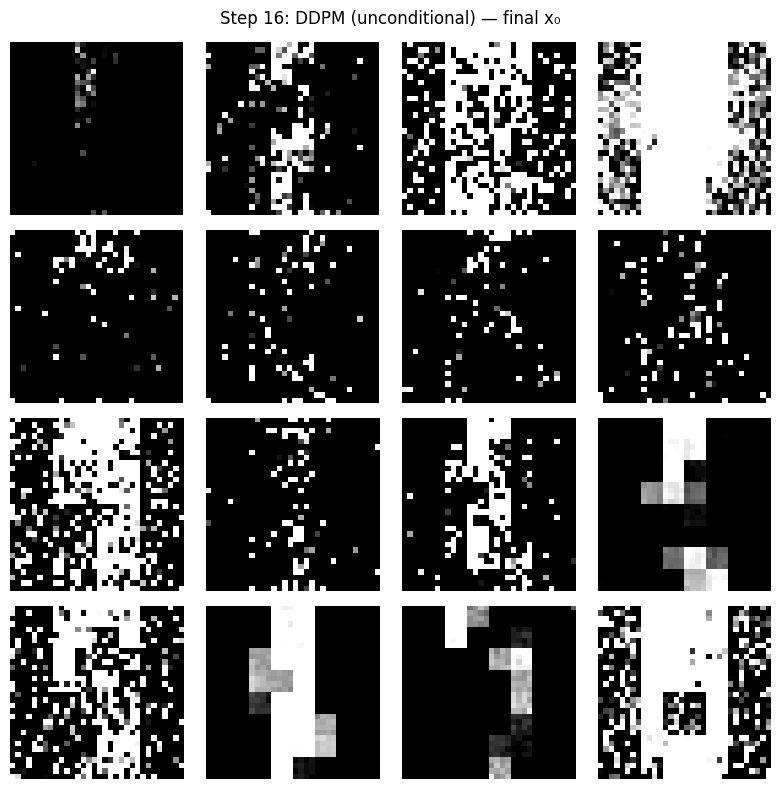

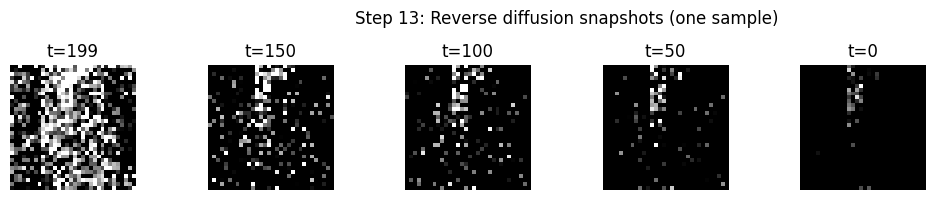

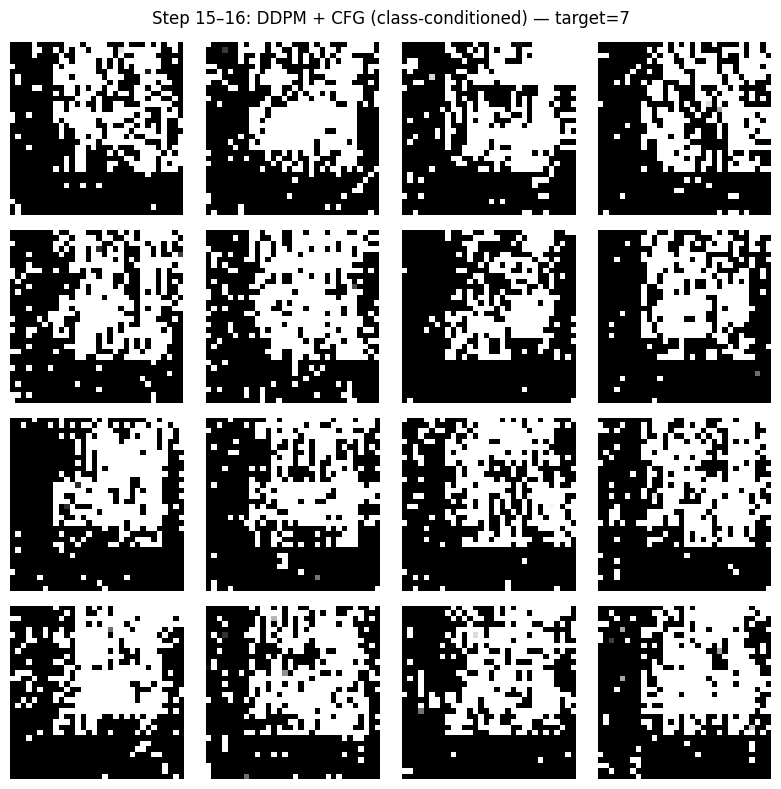

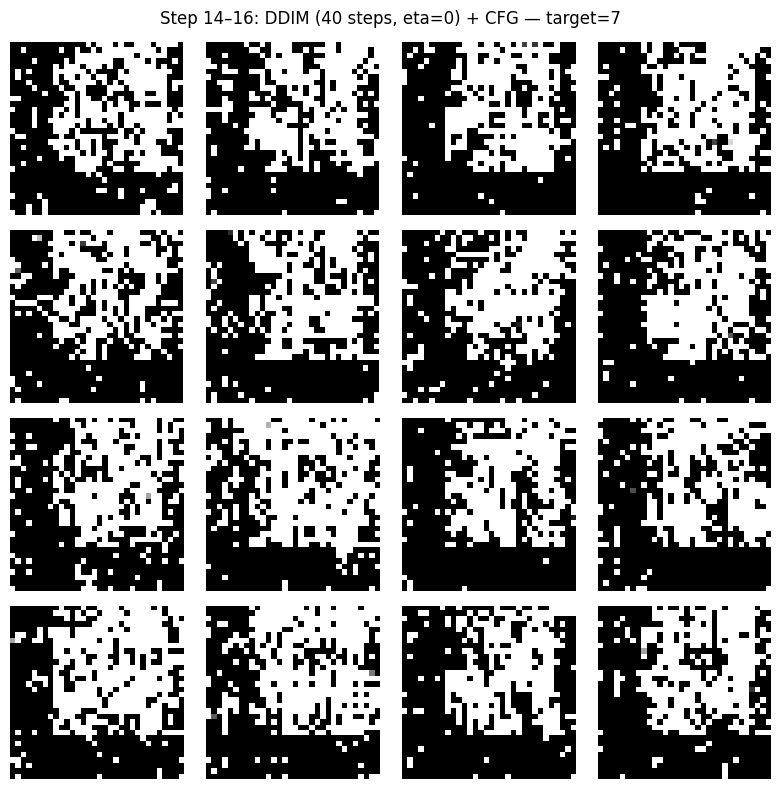

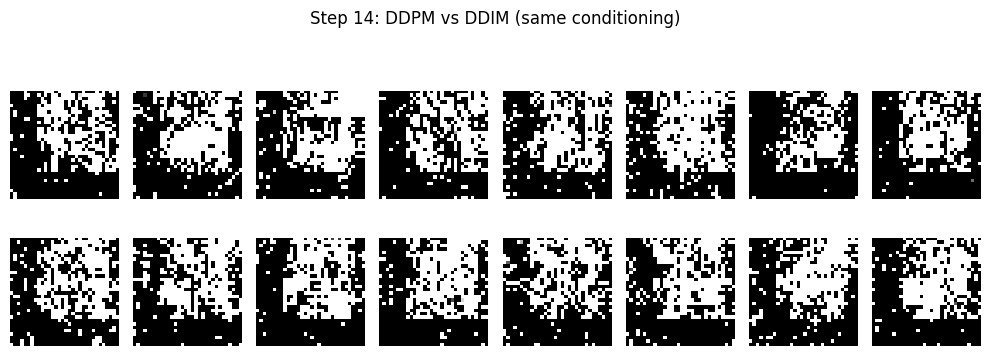

In [ ]:
# ============================================================
# 1️⃣6️⃣ Final Output Visualizations
# ============================================================

# Unconditional DDPM
final_u, snaps = sample_ddpm(n=16, y=None, cfg_scale=0.0)
show_grid(final_u.to(device), "Step 16: DDPM (unconditional) — final x₀")

# Reverse snapshots (one sample)
keys = sorted(snaps.keys(), reverse=True)
plt.figure(figsize=(12,2))
for i, t in enumerate(keys[:6]):
    plt.subplot(1, 6, i+1)
    img = to_01(snaps[t])[0,0]
    plt.imshow(img, cmap="gray"); plt.axis("off"); plt.title(f"t={t}")
plt.suptitle("Step 13: Reverse diffusion snapshots (one sample)")
plt.tight_layout(); plt.show()

# Conditional + CFG
target_digit = 7
y_cond = torch.full((16,), target_digit, device=device, dtype=torch.long)

final_cfg, _ = sample_ddpm(n=16, y=y_cond, cfg_scale=4.0)
show_grid(final_cfg.to(device), f"Step 15–16: DDPM + CFG (class-conditioned) — target={target_digit}")

# DDIM + CFG (faster sampling)
final_ddim = sample_ddim(n=16, y=y_cond, cfg_scale=4.0, ddim_steps=40, eta=0.0)
show_grid(final_ddim.to(device), f"Step 14–16: DDIM (40 steps, eta=0) + CFG — target={target_digit}")

# Side-by-side: DDPM vs DDIM
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2, 8, i+1)
    plt.imshow(to_01(final_cfg)[i,0], cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("DDPM+CFG")
    plt.subplot(2, 8, 8+i+1)
    plt.imshow(to_01(final_ddim)[i,0], cmap="gray")
    plt.axis("off")
    if i == 0: plt.ylabel("DDIM+CFG")
plt.suptitle("Step 14: DDPM vs DDIM (same conditioning)")
plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# 1️⃣7️⃣ Optional Decoder (Latent Diffusion note)
# ============================================================
# In Latent Diffusion (Stable Diffusion):
#   pixel image x0 -> VAE encoder -> latent z0
#   diffusion runs in latent space (z_t)
#   after sampling: z0 -> VAE decoder -> pixel image
#
# This lab runs diffusion directly in pixel space for clarity.

print("✅ End-to-end diffusion lab complete (DDPM + DDIM + CFG + visuals).")

✅ End-to-end diffusion lab complete (DDPM + DDIM + CFG + visuals).


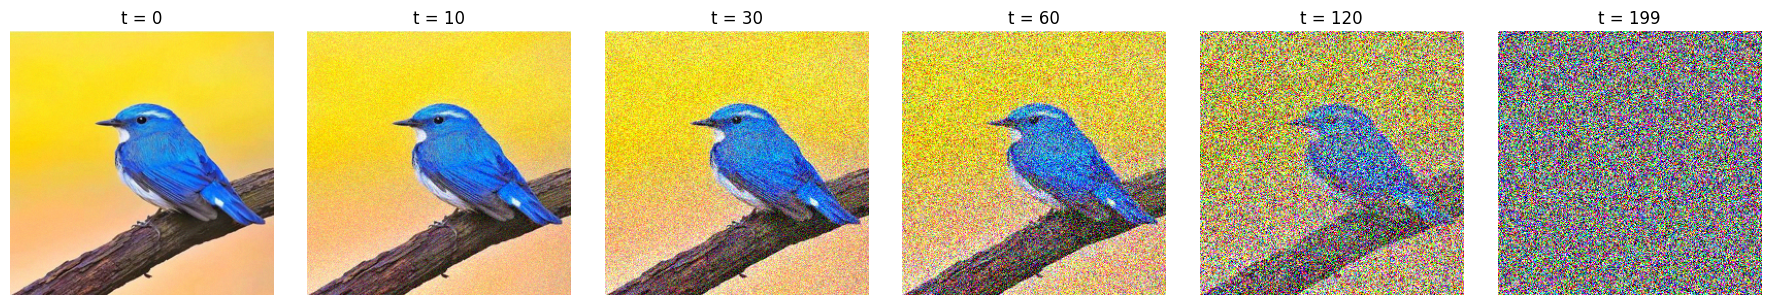

x_T mean: 0.0028674467466771603 | std: 0.9979864358901978


In [ ]:
# ============================================================
# Forward Diffusion on a Custom Image (x0 -> xT ~ Gaussian noise)
# Horizontal Visualization (Single Cell)
# ============================================================

IMAGE_PATH = "mybird.jpg"   # <-- upload your image first

import math
import torch
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Visualization helper (subplot-friendly)
# ------------------------------------------------------------
def show_on_ax(ax, img, title=""):
    img = img.detach().cpu()
    img = (img + 1) / 2          # [-1,1] → [0,1]
    img = img.clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.axis("off")
    ax.set_title(title)

# ------------------------------------------------------------
# Beta schedules
# ------------------------------------------------------------
def make_beta_schedule(T_steps, schedule="cosine", beta_start=1e-4, beta_end=0.02):
    if schedule == "linear":
        return torch.linspace(beta_start, beta_end, T_steps)
    if schedule == "cosine":
        s = 0.008
        steps = torch.arange(T_steps + 1, dtype=torch.float32)
        t = steps / T_steps
        alpha_bar = torch.cos(((t + s) / (1 + s)) * math.pi / 2) ** 2
        alpha_bar = alpha_bar / alpha_bar[0]
        betas = 1 - (alpha_bar[1:] / alpha_bar[:-1])
        return betas.clamp(1e-5, 0.999)
    raise ValueError("schedule must be 'linear' or 'cosine'")

def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))

# ------------------------------------------------------------
# Load and normalize image to [-1, 1]
# ------------------------------------------------------------
img = Image.open(IMAGE_PATH).convert("RGB")
img = img.resize((256, 256))

x0 = torch.from_numpy(
    (torch.tensor(list(img.getdata()))
     .view(img.size[1], img.size[0], 3)
     .numpy())
).float() / 255.0

x0 = x0.permute(2, 0, 1)     # CHW
x0 = x0 * 2 - 1              # [-1,1]
x0 = x0.unsqueeze(0).to(device)  # BCHW

# ------------------------------------------------------------
# Diffusion schedule
# ------------------------------------------------------------
T_steps = 200
betas = make_beta_schedule(T_steps, schedule="cosine").to(device)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0) # cumulative product

sqrt_alpha_bar = torch.sqrt(alpha_bar)
sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - alpha_bar)

# ------------------------------------------------------------
# Forward diffusion process q(x_t | x_0)
# ------------------------------------------------------------
def q_sample(x0, t, eps=None):
    if eps is None:
        eps = torch.randn_like(x0)
    return (
        extract(sqrt_alpha_bar, t, x0.shape) * x0 +
        extract(sqrt_one_minus_alpha_bar, t, x0.shape) * eps
    )

# ------------------------------------------------------------
# Horizontal visualization of diffusion steps
# ------------------------------------------------------------
timesteps = [0, 10, 30, 60, 120, 199]

fig, axes = plt.subplots(1, len(timesteps), figsize=(3 * len(timesteps), 3))

for ax, tv in zip(axes, timesteps):
    t = torch.tensor([tv], device=device, dtype=torch.long)
    xt = q_sample(x0, t)
    show_on_ax(ax, xt[0], f"t = {tv}")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Verify x_T ≈ N(0, I)
# ------------------------------------------------------------
tT = torch.tensor([T_steps - 1], device=device, dtype=torch.long)
xT = q_sample(x0, tT)

print(
    "x_T mean:", float(xT.mean().detach().cpu()),
    "| std:", float(xT.std().detach().cpu())
)

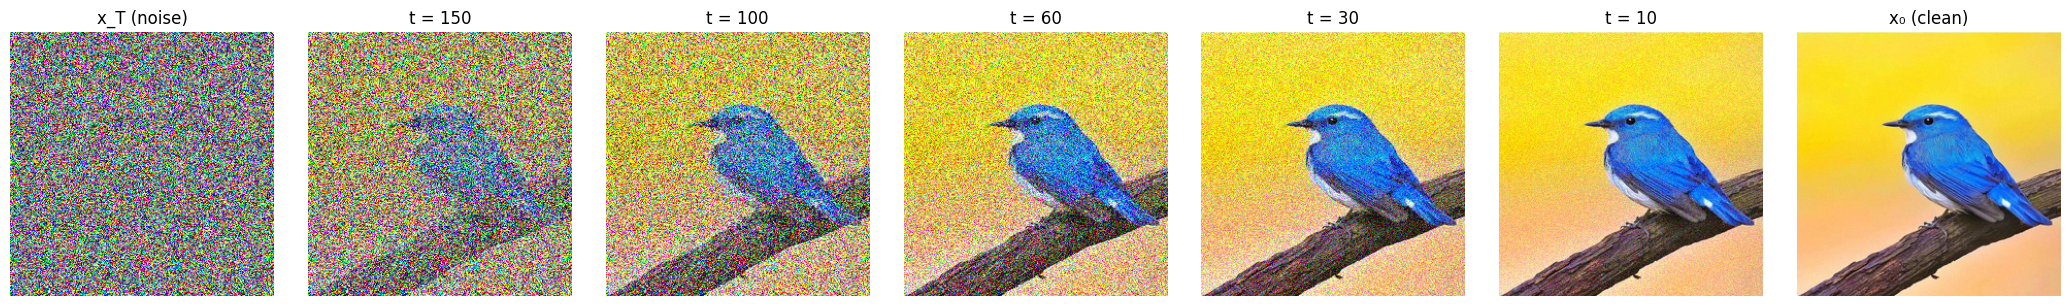

In [ ]:
# ============================================================
# Reverse Diffusion (ORACLE denoising – NO model)
# Purpose:
#   Start from near-pure Gaussian noise
#   Gradually remove noise using perfect ε
#   End exactly at the clean image x0
# ============================================================

import torch
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Visualization helpers
# ------------------------------------------------------------
def to_01(x):
    return ((x + 1) / 2).clamp(0, 1)

def show_on_ax(ax, x, title=""):
    x = x.detach().cpu()[0]
    ax.imshow(to_01(x).permute(1, 2, 0).numpy())
    ax.axis("off")
    ax.set_title(title)

def extract(vec, t, x_shape):
    out = vec.gather(0, t)
    return out.view(t.shape[0], *((1,) * (len(x_shape) - 1)))

# ------------------------------------------------------------
# Forward diffusion (minimal)
# ------------------------------------------------------------
def q_sample(x0, t, eps):
    return (
        extract(torch.sqrt(alpha_bar), t, x0.shape) * x0 +
        extract(torch.sqrt(1 - alpha_bar), t, x0.shape) * eps
    )

# ------------------------------------------------------------
# Oracle reverse diffusion visualization
# ------------------------------------------------------------
@torch.no_grad()
def visualize_oracle_reverse(
    x0,
    T_steps,
    steps_to_show=(199, 150, 100, 60, 30, 10, 0)
):
    """
    Horizontal visualization:
    pure noise → decreasing noise → clean image

    Because eps is fixed (oracle knowledge of the exact noise used),
    x_t at ANY timestep t can be computed directly from x0 via the
    forward formula:
        x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * eps
    This avoids compounding iterative error and guarantees a strictly
    monotonic noise -> clean progression, landing exactly on x0 at t=0.
    """

    # 1) fixed Gaussian noise ε (identical noise reused at every t)
    eps = torch.randn_like(x0)

    # 2) directly compute the noisy image at each requested timestep
    snapshots = {}
    for t_int in steps_to_show:
        t = torch.tensor([t_int], device=device)
        snapshots[t_int] = q_sample(x0, t, eps).clone()

    # 3) horizontal plot, ordered noisiest -> cleanest
    ordered_ts = sorted(snapshots.keys(), reverse=True)
    t_max = ordered_ts[0]
    fig, axes = plt.subplots(1, len(ordered_ts), figsize=(3 * len(ordered_ts), 3))

    for ax, t_int in zip(axes, ordered_ts):
        title = (
            "x_T (noise)" if t_int == t_max
            else "x₀ (clean)" if t_int == 0
            else f"t = {t_int}"
        )
        show_on_ax(ax, snapshots[t_int], title)

    plt.tight_layout()
    plt.show()

    return snapshots[0]

# ------------------------------------------------------------
# RUN (x0, alpha_bar, T_steps must already exist)
# ------------------------------------------------------------
restored = visualize_oracle_reverse(x0.to(device), T_steps)